<a href="https://colab.research.google.com/github/Goutham345/devops-task-app/blob/main/hpcproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Sample:
   temperature   humidity  wind_speed     target
0    27.490802  52.418449   10.949975  26.229418
1    39.014286  49.974726    2.767680  43.294904
2    34.639879  40.569235    5.199595  37.971237
3    31.973170  66.436000    9.949210  33.435041
4    23.120373  58.597450    7.231340  22.434221


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)



--- Performance ---
Sequential Time: 0.0374 sec
Parallel Time: 6.5870 sec
Speedup: 0.01x

--- Accuracy ---
RMSE (Sequential): 0.0616
RMSE (Parallel): 0.0616


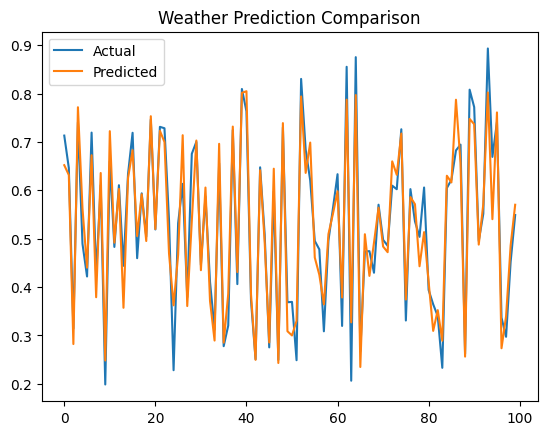

In [1]:
# STEP 1: Install required libraries
!pip install numpy pandas matplotlib scikit-learn joblib

# STEP 2: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from joblib import Parallel, delayed
import time

# STEP 3: Generate synthetic weather dataset (like ERA5 simulation)
np.random.seed(42)
n_samples = 10000

temperature = np.random.uniform(20, 40, n_samples)
humidity = np.random.uniform(30, 90, n_samples)
wind_speed = np.random.uniform(0, 15, n_samples)

# Target (next hour temperature prediction)
target_temp = temperature + np.random.normal(0, 2, n_samples)

data = pd.DataFrame({
    "temperature": temperature,
    "humidity": humidity,
    "wind_speed": wind_speed,
    "target": target_temp
})

print("Dataset Sample:")
print(data.head())

# STEP 4: Preprocessing (Normalization)
data_norm = (data - data.min()) / (data.max() - data.min())

X = data_norm[['temperature', 'humidity', 'wind_speed']]
y = data_norm['target']

# STEP 5: Split dataset
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# STEP 6: Sequential Training
start_time = time.time()
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_seq = model.predict(X_test)
seq_time = time.time() - start_time

# STEP 7: Parallel Prediction (simulate MPI-like speedup)
def parallel_predict(chunk):
    return model.predict(chunk)

chunks = np.array_split(X_test, 4)

start_time = time.time()
results = Parallel(n_jobs=4)(delayed(parallel_predict)(chunk) for chunk in chunks)
y_pred_parallel = np.concatenate(results)
par_time = time.time() - start_time

# STEP 8: Evaluation
rmse_seq = np.sqrt(mean_squared_error(y_test, y_pred_seq))
rmse_par = np.sqrt(mean_squared_error(y_test, y_pred_parallel))

print("\n--- Performance ---")
print(f"Sequential Time: {seq_time:.4f} sec")
print(f"Parallel Time: {par_time:.4f} sec")
print(f"Speedup: {seq_time / par_time:.2f}x")

print("\n--- Accuracy ---")
print(f"RMSE (Sequential): {rmse_seq:.4f}")
print(f"RMSE (Parallel): {rmse_par:.4f}")

# STEP 9: Visualization
plt.figure()
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred_parallel[:100], label="Predicted")
plt.legend()
plt.title("Weather Prediction Comparison")
plt.show()